# Gaussian Process Regression — Extrapolating VQE Performance to Larger Qubit Counts

**Thomas Griffiths** — Quantum Computing Course (PH10110), University of Edinburgh

Real quantum hardware time is scarce, so before spending it we want to know
which VQE configuration (ansatz, repetitions, optimizer) is most likely to
perform well at a target qubit count — here, 12 qubits, the size used for the
real IBM hardware runs in `IBM.ipynb`. This notebook trains a **Gaussian
Process Regressor (GPR)** on the 72-configuration sweep produced by
`Sweep.ipynb` (4, 6, 8 qubits, noisy simulation) and extrapolates expected
error out to 10–20 qubits, selecting the best-performing configuration at
each target size.

A GPR was chosen specifically because it returns calibrated uncertainty
bands outside the training range — important here, since any extrapolation
beyond 8 qubits is by definition outside what was actually measured, and we
need to know not just the predicted error but how much to trust it.

## This notebook covers
1. **Data preparation** — load the sweep CSV, engineer `depth_per_qubit` and
   ordinal encodings for the categorical ansatz/optimizer features.
2. **GPR kernel** — a Matérn kernel (+ white noise) fit on standardized
   features, predicting log mean-absolute-energy-error.
3. **Held-out validation** — leave-one-qubit-count-out cross-validation
   ($R^2$, MAE, and 1σ coverage) to check the model isn't just memorizing.
4. **Scaling laws** — a separate linear regression maps qubit count → circuit
   depth per (ansatz, reps) combination, needed to generate input features for
   qubit counts (10–20) that were never actually simulated.
5. **Extrapolation & reliability horizon** — final GPR predictions out to 20
   qubits, with an explicit "reliability horizon" (training boundary + one
   kernel length-scale) marking where extrapolation confidence drops off, and
   a ranked-configuration heatmap/bar chart for picking the best setup at each
   target qubit count.

## Input data
Expects `Results/multiqubit_sweep_results2.csv` — the fixed output location
used by `Sweep.ipynb`. The repository already includes the populated file
from the sweep that produced the results in the final report, so this
notebook can be run without first re-running `Sweep.ipynb`.

In [124]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel, DotProduct
from sklearn.metrics import r2_score
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor

SEED = 64

warnings.filterwarnings('ignore', category=ConvergenceWarning)

Reading in the multisweep data, dropping the duplicate columns so they organize better in the dataframe, and creating a new parameter 'depth_per_qubit' which is handy for understanding how the different configurations extend the operations on the system on a qubit level.

# Step 1: Dataframe Creation

In [125]:
# Features: ansatz,reps,optimizer,n_qubits,n_params,circuit_depth,jz,E_vqe,E_exact,energy_error,Spi_vqe,Spi_exact,wall_time,mean_abs_error,max_abs_error,total_time_s
df = pd.read_csv('Results/multiqubit_sweep_results2.csv')
df = df.drop_duplicates(subset=['ansatz', 'reps', 'optimizer', 'n_qubits'], keep='first')  # Remove duplicates based on specific columns
df['depth_per_qubit'] = df['circuit_depth'] / df['n_qubits']  # Create a new column for depth per qubit
df

,ansatz,reps,optimizer,n_qubits,n_params,circuit_depth,jz,E_vqe,E_exact,energy_error,Spi_vqe,Spi_exact,wall_time,mean_abs_error,max_abs_error,total_time_s,depth_per_qubit
0,efficient_su2,1,SPSA,4,16,7,-3.0,-8.824605,-9.0,0.175395,-0.496783,-0.5,3.216221,1.650030,7.554798,77.983888,1.750
25,efficient_su2,1,COBYLA,4,16,7,-3.0,-8.867085,-9.0,0.132915,-0.496043,-0.5,2.010956,0.458375,1.272022,31.565572,1.750
50,efficient_su2,1,NFT,4,16,7,-3.0,-8.890301,-9.0,0.109699,-0.498122,-0.5,5.201178,0.296495,0.787319,116.542827,1.750
75,efficient_su2,1,QNSPSA,4,16,7,-3.0,-8.879760,-9.0,0.120240,-0.493772,-0.5,20.667626,0.584870,1.450503,565.740868,1.750
100,efficient_su2,2,SPSA,4,24,11,-3.0,-8.814697,-9.0,0.185303,-0.489595,-0.5,2.989276,1.249486,4.218609,79.704118,2.750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1675,n_local,1,QNSPSA,8,32,31,-3.0,-16.904029,-21.0,4.095971,-0.389488,-0.5,125.942929,3.907492,9.956493,4060.944625,3.875
1700,n_local,2,SPSA,8,48,54,-3.0,-20.352738,-21.0,0.647262,-0.499425,-0.5,27.348309,5.352147,13.631358,672.172580,6.750
1725,n_local,2,COBYLA,8,48,54,-3.0,-18.930455,-21.0,2.069545,-0.439921,-0.5,14.341303,3.866776,10.290606,366.408566,6.750
1750,n_local,2,NFT,8,48,54,-3.0,-17.547354,-21.0,3.452646,-0.436103,-0.5,38.063372,2.859183,5.998833,904.084664,6.750


# Step 2: Feature Engineering

In [126]:
# Ranking the ansatz and optimizer based on mean depth per qubit and mean total time respectively
rank1 = df.groupby('ansatz')['depth_per_qubit'].mean().sort_values()
rank2 = df.groupby('optimizer')['total_time_s'].mean().sort_values()
print(rank1)
print(f"\n {rank2}")

ansatz
real_amplitudes    1.451389
efficient_su2      1.902778
n_local            5.229167
Name: depth_per_qubit, dtype: float64

 optimizer
COBYLA     149.006295
SPSA       243.769463
NFT        355.905822
QNSPSA    1840.624349
Name: total_time_s, dtype: float64


In [127]:
# Creating mapping dictionaries for ansatz and optimizer to convert categorical variables into ordinal integers for modeling
ansatz_map = {f: i for i, f in enumerate(rank1.index)}
optimizer_map = {f: i for i, f in enumerate(rank2.index)}

df['ansatz_ord'] = df['ansatz'].map(ansatz_map)
df['optimizer_ord'] = df['optimizer'].map(optimizer_map)
print(ansatz_map, optimizer_map)

{'real_amplitudes': 0, 'efficient_su2': 1, 'n_local': 2} {'COBYLA': 0, 'SPSA': 1, 'NFT': 2, 'QNSPSA': 3}


In [128]:
# Log transform the mean absolute error to reduce skewness in the data distribution
df['mean_abs_error_log'] = np.log(df['mean_abs_error'])  # Reduces skewness (0.96 -> -0.26)

In [129]:
# Define the features and target variable for the Gaussian Process Regression model
# n_params is absent asa it is correlated with depth_per_qubit, excluded to avoid multicollinearity issues
features = ['ansatz_ord', 'optimizer_ord', 'reps', 'n_qubits', 'depth_per_qubit']
target = 'mean_abs_error_log'

X = df[features].values
Y = df[target].values

# Standardize the features to have zero mean and unit variance, which is important for Gaussian Process Regression as it assumes the input features are on similar scales
scaler = StandardScaler().fit(X)
X_sc = scaler.transform(X)
print('means:', X_sc.mean(axis=0), 'stds:', X_sc.std(axis=0))

means: [0. 0. 0. 0. 0.] stds: [1. 1. 1. 1. 1.]


# Step 3: Building Gaussian Process Regression Kernel

In [130]:
# Set a random seed for reproducibility of results
rng = np.random.default_rng(SEED)

# Define the kernel for the Gaussian Process Regression model. The kernel is a combination of a constant kernel multiplied by a Matern kernel and a white noise kernel. The Matern kernel is parameterized with a length scale and smoothness parameter (nu), while the white noise kernel accounts for noise in the simulations.
# The values were set based on the scale of the features and the expected noise in the data. The length scale bounds were set to allow for flexibility in fitting the model to the data.
# With the exact scale bounds describing the amount of standard deviations the feature can vary before there is a significant change in the output. The noise level bounds were set to allow for a wide range of noise levels in the data, from very low to very high.

kernel = (ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale = [1.]*5, length_scale_bounds=(1e-2, 1e3), nu=1.5)) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 10))

# Create the Gaussian Process Regressor model with the defined kerne and specifying the number of restarts for the optimizer to find the best hyperparameters as to not get trapped in local minima. 
# The model is also set to normalize the target variable to have zero mean and unit variance, which can improve the performance of the model by making it easier to learn the underlying patterns in the data.
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=15, normalize_y = True, random_state=SEED)
gpr.fit(X_sc, Y)
gpr.kernel_

1.58**2 * Matern(length_scale=[6.22, 0.012, 16.3, 5.14, 1e+03], nu=1.5) + WhiteKernel(noise_level=0.0641)

In [131]:
dict(zip(features, gpr.kernel_.k1.k2.length_scale))

{'ansatz_ord': np.float64(6.22356073672342),
 'optimizer_ord': np.float64(0.012045386415893193),
 'reps': np.float64(16.335511967500857),
 'n_qubits': np.float64(5.13593480094125),
 'depth_per_qubit': np.float64(999.9999999999998)}

Switching from a length scale bound of 1e2 and 1e3 only significantly changes the depth feature as in both cases it pins to the set bound. This means that the model is not sensitive to the depth feature and it is not contributing to the prediction of the target variable. The other features have length scales that are within the bounds, indicating that they are contributing to the prediction of the target variable. This suggests that the model is able to learn from the other features and make accurate predictions even without considering the depth feature.

The physical reasoning behind the depth pinning is due to the fact that it is not a configuration choice and more so a consequence of the other choices. Changing ansatz/reps dictates how deep the circuit is, therefore, the depth_per_qubit doesn't actively alter the error reduction.


In [132]:
# We want to test the model extrapolates the results with varying train/test datasets. As although the model is designed to extrapolate for larger qubit counts, the larger qubit count systems have more data to train on. 
# Therefore, we will train the model on all but one qubit count and test on the remaining qubit count to see how well the model extrapolates to unseen data.

for n_qubits in [4, 6, 8]:
    # Split the data into training and testing sets based on the number of qubits
    df_train = df[df['n_qubits'] != n_qubits]
    df_test = df[df['n_qubits'] == n_qubits]

    X_train = df_train[features].values
    Y_train = df_train[target].values
    X_test = df_test[features].values
    Y_test = df_test[target].values

    # Standardize the training and testing features using the same scaler fitted on the training data
    scaler_fold = StandardScaler().fit(X_train)
    X_train_sc = scaler_fold.transform(X_train)
    X_test_sc = scaler_fold.transform(X_test)

    # Fit the Gaussian Process Regressor model on the training data
    gpr_cv = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=15, normalize_y=True, random_state=SEED)
    gpr_cv.fit(X_train_sc, Y_train)

    # Make predictions on the test data and obtain the mean and standard deviation of the predictions
    Y_pred, Y_std = gpr_cv.predict(X_test_sc, return_std=True)

    # Calculate the mean absolute error and R^2 score of the predictions to evaluate the model's performance
    mae = np.mean(np.abs(Y_pred - Y_test))
    r2 = r2_score(Y_test, Y_pred)

    coverage = np.mean(np.abs(Y_test - Y_pred) <=  Y_std)
    
    print(f"Mean Absolute Error for {n_qubits} qubits: {mae:.4f}, R^2 Score: {r2:.4f}")
    print(f"Coverage of 1-sigma uncertainty band: {coverage:.4f}")
    

Mean Absolute Error for 4 qubits: 0.6327, R^2 Score: -0.1947
Coverage of 1-sigma uncertainty band: 0.3333
Mean Absolute Error for 6 qubits: 0.5486, R^2 Score: -0.0388
Coverage of 1-sigma uncertainty band: 0.8333
Mean Absolute Error for 8 qubits: 0.2183, R^2 Score: 0.7665
Coverage of 1-sigma uncertainty band: 0.8750


$R^{2}$ is a fraction of variance in the true values explained by the prediction. Therefore, values of 1.0 are perfect, while 0.0 refers to no better then just guessing the training mean, and negative means it is actively worse then guessing. Here we see the model performs better testing on 8 qubits, with only $77\%$ variance. 

The mean absolute error is taken from log-space and now the raw magnitudes. Again here the 8 qubit held-out performs the best.

The coverage describes what fraction of true test points fall inside the model's own $\pm1 \sigma$ band. A value  $\approx 68 \%$ describes a well-calibrated Gaussian, while values below are overconfident and values above have a conservative model band which is wider than needed. The 4 qubit performs the worst, with only 1 in 3 true values landing within the model band. The held-out-6 model remains reasonably calibrated, while the 8 qubit leans more conservatively.

Considering the results and the goals of the model, holding out on training the 8-qubit results allows the model to better extrapolate results for larger qubit systems while maintaining high model performance.

One thing to note: fiddling with the length scale lower bound ($1e-2 \rightarrow 1e-3$) as to accomodate the underpinning of the optimizer choice led the forward-extrapolation $R^2: 0.77 \rightarrow -0.0377$. This result could be due to overfitting from too much model flexibility.The lower length-scale bound was set to $1e-2$ to avoid the kernel collapsing optimizer_ord towards a small length-scale.

# Step 5. Scaling Laws for Unseen Qubit Counts (10-20)

For extrapolating to large systems, we need values of depth_per_qubit for those configurations as the VQE's were never simulated to those circuit depths. To inlude these, we need to scale n_qubits for a given ansatz/rep. Employing a linear regression model to fit the ansatz and reps to larger qubit counts.

In [133]:
# Grouping the ansatz/reps and training a LinearRegression Model to fit the depth per qubit to larger qubit systems:
scalers = {}

for (ansatz, reps), grp in df.groupby(['ansatz', 'reps']):
   Xg = grp[['n_qubits']].values
   Yg = grp['circuit_depth'].values
   lr = LinearRegression().fit(Xg, Yg)
   r2 = lr.score(Xg, Yg)
   scalers[(ansatz, reps)] = (lr.coef_[0], lr.intercept_)
   print(f"Ansatz: {ansatz}, Reps: {reps}, Slope: {lr.coef_[0]:.4f}, Intercept: {lr.intercept_:.4f}, R^2 Score: {r2:.4f}")

slope, intercept = scalers[('real_amplitudes', 1)]

Ansatz: efficient_su2, Reps: 1, Slope: 1.0000, Intercept: 3.0000, R^2 Score: 1.0000
Ansatz: efficient_su2, Reps: 2, Slope: 1.0000, Intercept: 7.0000, R^2 Score: 1.0000
Ansatz: n_local, Reps: 1, Slope: 4.0000, Intercept: -1.0000, R^2 Score: 1.0000
Ansatz: n_local, Reps: 2, Slope: 7.0000, Intercept: -2.0000, R^2 Score: 1.0000
Ansatz: real_amplitudes, Reps: 1, Slope: 1.0000, Intercept: 1.0000, R^2 Score: 1.0000
Ansatz: real_amplitudes, Reps: 2, Slope: 1.0000, Intercept: 4.0000, R^2 Score: 1.0000


As expected, the scaling between the number of qubits and the circuit depth is linear when grouped with ansatz and repetitions ($R^2 = 1$)

In [134]:
# Extrapolate depth per qubit by computing depth = slope * n_qubits + intercept for a given ansatz and reps. This function will allow us to predict the circuit depth for larger qubit systems based on the linear relationship.

def extrapolate_depth(ansatz, reps, n_qubits):
    slope, intercept = scalers[(ansatz, reps)]
    depth = slope * n_qubits + intercept
    return depth / n_qubits  # Return depth per qubit

# Sanity Check
real_value = df[(df['ansatz'] == 'real_amplitudes') & (df['reps'] == 1) & (df['n_qubits'] == 8)]['depth_per_qubit'].values[0]
print(real_value, extrapolate_depth('real_amplitudes', 1, 8))

1.125 1.125


In [135]:
target_q = [10, 12, 14, 16, 18, 20]

# Get unique combinations of ansatz, reps, and optimizer to evaluate the model's predictions for different configurations

comb = df[['ansatz', 'reps', 'optimizer']].drop_duplicates().values
rows = []
for ansatz, reps, optimizer in comb:
    for n_qubits in target_q:
        depth_per_qubit = extrapolate_depth(ansatz, reps, n_qubits)
        rows.append([ansatz, reps, optimizer, n_qubits, depth_per_qubit])

df_new = pd.DataFrame(rows, columns=['ansatz', 'reps', 'optimizer', 'n_qubits', 'depth_per_qubit'])
df_new


,ansatz,reps,optimizer,n_qubits,depth_per_qubit
0,efficient_su2,1,SPSA,10,1.300000
1,efficient_su2,1,SPSA,12,1.250000
2,efficient_su2,1,SPSA,14,1.214286
3,efficient_su2,1,SPSA,16,1.187500
4,efficient_su2,1,SPSA,18,1.166667
...,...,...,...,...,...
139,n_local,2,QNSPSA,12,6.833333
140,n_local,2,QNSPSA,14,6.857143
141,n_local,2,QNSPSA,16,6.875000
142,n_local,2,QNSPSA,18,6.888889


In [136]:
# Checking the mapping of ansatz and optimizer to ordinal integers for the new DataFrame to ensure consistency with the original DataFrame
df_new['ansatz_ord'] = df_new['ansatz'].map(ansatz_map)
df_new['optimizer_ord'] = df_new['optimizer'].map(optimizer_map)

df_new[features].head()

,ansatz_ord,optimizer_ord,reps,n_qubits,depth_per_qubit
0,1,1,1,10,1.300000
1,1,1,1,12,1.250000
2,1,1,1,14,1.214286
3,1,1,1,16,1.187500
4,1,1,1,18,1.166667


In [137]:
df_train = df[df['n_qubits'] <= 8] 

X_train = df_train[features].values
Y_train = df_train[target].values

X_extrap = df_new[features].values

scaler_final = StandardScaler().fit(X_train)
X_train_sc = scaler_final.transform(X_train)
X_sc = scaler_final.transform(X_extrap)

gpr_final = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=15, normalize_y=True, random_state=SEED)
gpr_final.fit(X_train_sc, Y_train)
pred_log, std_log = gpr_final.predict(X_sc, return_std=True)

df_new['pred_log'] = pred_log
df_new['std_log'] = std_log

# 3 New columns:
# Pred_median = np.exp(pred_log)
# Pred_low = np.exp(pred_log - std_log)
# Pred_high = np.exp(pred_log + std_log)

# df_new['pred_median'] = np.exp(pred_low[0])
# df_new['pred_low'] = np.exp(pred_low[0] - pred_low[1])
# df_new['pred_high'] = np.exp(pred_low[0] + pred_low[1])

# Instead try exp(mu_log + 0.5 * sig_log**2) instead of np.exp(pred_log)
df_new["pred_median_corrected"] = np.exp(pred_log + 0.5 * std_log**2)
df_new["pred_low_cr"] = np.exp(pred_log - std_log + 0.5*std_log**2)
df_new["pred_high_cr"] = np.exp(pred_log + std_log + 0.5*std_log**2)

df_new.head()

,ansatz,reps,optimizer,n_qubits,depth_per_qubit,ansatz_ord,optimizer_ord,pred_log,std_log,pred_median_corrected,pred_low_cr,pred_high_cr
0,efficient_su2,1,SPSA,10,1.300000,1,1,1.574245,0.428887,5.292109,3.446398,8.126287
1,efficient_su2,1,SPSA,12,1.250000,1,1,1.494284,0.704585,5.711624,2.823334,11.554654
2,efficient_su2,1,SPSA,14,1.214286,1,1,1.330495,0.925394,5.804726,2.300849,14.644525
3,efficient_su2,1,SPSA,16,1.187500,1,1,1.146682,1.077302,5.623604,1.914909,16.515100
4,efficient_su2,1,SPSA,18,1.166667,1,1,0.974748,1.174501,5.282895,1.632272,17.098243


In [138]:
print(gpr_final.kernel_)

1.58**2 * Matern(length_scale=[6.22, 0.012, 16.3, 5.14, 1e+03], nu=1.5) + WhiteKernel(noise_level=0.0641)


In [139]:
check = df[(df.ansatz == 'efficient_su2') & (df.reps == 1) & (df.optimizer == 'SPSA')][['n_qubits', 'mean_abs_error', 'depth_per_qubit']].sort_values('n_qubits')
check

,n_qubits,mean_abs_error,depth_per_qubit
0,4,1.650030,1.750
600,6,3.037418,1.500
1200,8,4.527332,1.375


In [140]:
check_extrap = df_new[(df_new.ansatz == 'efficient_su2') & (df_new.reps == 1) & (df_new.optimizer == 'SPSA')][['n_qubits', 'pred_median_corrected', 'pred_low_cr', 'pred_high_cr', 'depth_per_qubit']].sort_values('n_qubits')
check_extrap

,n_qubits,pred_median_corrected,pred_low_cr,pred_high_cr,depth_per_qubit
0,10,5.292109,3.446398,8.126287,1.300000
1,12,5.711624,2.823334,11.554654,1.250000
2,14,5.804726,2.300849,14.644525,1.214286
3,16,5.623604,1.914909,16.515100,1.187500
4,18,5.282895,1.632272,17.098243,1.166667
5,20,4.897313,1.426060,16.818134,1.150000


In [141]:
check_extrap2 = df_new[(df_new.ansatz == 'n_local') & (df_new.reps == 2) & (df_new.optimizer == "SPSA")][['n_qubits', 'pred_median_corrected', 'pred_low_cr', 'pred_high_cr', 'depth_per_qubit']].sort_values('n_qubits')
check_extrap2

,n_qubits,pred_median_corrected,pred_low_cr,pred_high_cr,depth_per_qubit
120,10,6.050905,3.841672,9.530603,6.800000
121,12,6.291214,3.047361,12.988083,6.833333
122,14,6.200760,2.427562,15.838698,6.857143
123,16,5.874120,1.986366,17.371061,6.875000
124,18,5.434507,1.672848,17.654840,6.888889
125,20,4.987494,1.449474,17.161459,6.900000


In [142]:
for n in [8, 10, 15, 20, 50, 100, 1000]:
    depth = extrapolate_depth('efficient_su2', 1, n)
    row = [[ansatz_map['efficient_su2'], optimizer_map['SPSA'], 1, n, depth]]
    pred_log, std_log = gpr_final.predict(scaler_final.transform(row), return_std=True)
    print(f"n={n:5d}: pred_median={np.exp(pred_log[0] + 0.5*std_log[0]**2):.4f}, std_log={std_log[0]:.4f}")

n=    8: pred_median=4.5149, std_log=0.2478
n=   10: pred_median=5.2921, std_log=0.4289
n=   15: pred_median=5.7421, std_log=1.0093
n=   20: pred_median=4.8973, std_log=1.2338
n=   50: pred_median=3.3537, std_log=1.3121
n=  100: pred_median=3.3437, std_log=1.3121
n= 1000: pred_median=3.3437, std_log=1.3121


# Try with DotProduct

As seen above, as we increase the number of qubits, the median error decreases back down to a constant. This doesn't follow a trend but instead the Matern kernel stops tracking the input structure and reverts towards the GP's prior mean. Therefore, the extrapolation is only good up til n ~ 14/15 before it begins to taper off. Obviously the widening continues to increase as the standard deviation goes from 0.4 -> 1.3 as the GPR grows in humility.

To actually extrapolate a trend rather than decaying back to a prior, we include a DotProduct term in  the kernel to build a linear drift to fall back on instead of going to a constant.

In [143]:
n_qubits_length_scale = dict(zip(features, gpr_final.kernel_.k1.k2.length_scale))['n_qubits']
n_qubits_length_scale * scaler_final.scale_[features.index('n_qubits')]  # This gives the length scale in the original units of n_qubits, which is important for interpreting the model's sensitivity to changes in the number of qubits.

np.float64(8.386946409672504)

In [144]:
kernel_with_linear = (ConstantKernel(1.0, (1e-3, 1e3)) * DotProduct(sigma_0 = 1.0)) + (ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale = [1.]*5, length_scale_bounds=(1e-2, 1e3), nu=1.5)) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 10)) 
gpr_ker = GaussianProcessRegressor(kernel=kernel_with_linear, n_restarts_optimizer=15, normalize_y=True, random_state=SEED)

gpr_ker.fit(X_train_sc, Y_train)
pred_low = gpr_ker.predict(X_sc, return_std=True)

print(gpr_ker.kernel_)

0.345**2 * DotProduct(sigma_0=1e-05) + 0.574**2 * Matern(length_scale=[3.35, 0.103, 3.7, 7.1, 1e+03], nu=1.5) + WhiteKernel(noise_level=0.0632)


In [145]:
for n in [8, 10, 15, 20, 50, 100, 1000]:
    depth = extrapolate_depth('efficient_su2', 1, n)
    row = [[ansatz_map['efficient_su2'], optimizer_map['SPSA'], 1, n, depth]]
    pred_log, std_log = gpr_ker.predict(scaler_final.transform(row), return_std=True)
    print(f"n={n:5d}: pred_median={np.exp(pred_log[0] + 0.5*std_log[0]**2):.4f}, std_log={std_log[0]:.4f}")

n=    8: pred_median=4.8271, std_log=0.2391
n=   10: pred_median=8.1028, std_log=0.2716
n=   15: pred_median=33.8808, std_log=0.4109
n=   20: pred_median=163.9412, std_log=0.5502
n=   50: pred_median=4815420.9768, std_log=1.2684
n=  100: pred_median=571739255559098.5000, std_log=2.5308
n= 1000: pred_median=15203990435061482917170436106158459661227726076993798833076411154162487526146103342813072529396295405320313835064966055785356779903416261233749369319459497925738741840155035440827849791045191556692642652634772002937383384916824076131226171489027425853808044376171164731944749400547972349952.0000, std_log=26.2133


# Analysis/Plotting

Since we are looking to test on n = 12 qubits for the real hardware runs, we'll stick with the Matern-Kernel GPR as the predictions stay anchored to the training data for ~ one length scale beyond the training boundary.This can be seen across two configurations with both increasing and decreasing depth_per_qubits with check_extrap and check_extrap2.

In [148]:
def lognormal_mean(mu, sigma):
    # Bias-corrected mean of exp(N(mu, sigma^2)) -> pred_median
    return np.exp(mu + 0.5*sigma**2)

def lognormal_band(mu, sigma):
    # Asymmetric +/- 1 sigma band (way to show GPR uncertainty)
    return np.exp(mu - sigma + 0.5*sigma**2), np.exp(mu + sigma + 0.5*sigma**2)

def lognormal_std(mu, sigma):
    # Standard Deviation
    return np.sqrt((np.exp(sigma**2) -1) * np.exp(2*mu + sigma ** 2))

def predict_curve(ansatz, reps, optimizer, q_values):
    # GPR (mu_log, sigma_log) for one config across a range of qubits
    rows = [[ansatz_map[ansatz], optimizer_map[optimizer], reps, q, extrapolate_depth(ansatz, reps, q)]
        for q in q_values]
    return gpr_final.predict(scaler_final.transform(rows), return_std = True)

def compute_reliability_horizon(train_boundary = 8):
    # Training Boundary + 1 Length-Scale on n_qubits
    ls_scaled = dict(zip(features, gpr_final.kernel_.k1.k2.length_scale))['n_qubits']
    ls_raw = ls_scaled * scaler_final.scale_[features.index('n_qubits')]
    return train_boundary + ls_raw

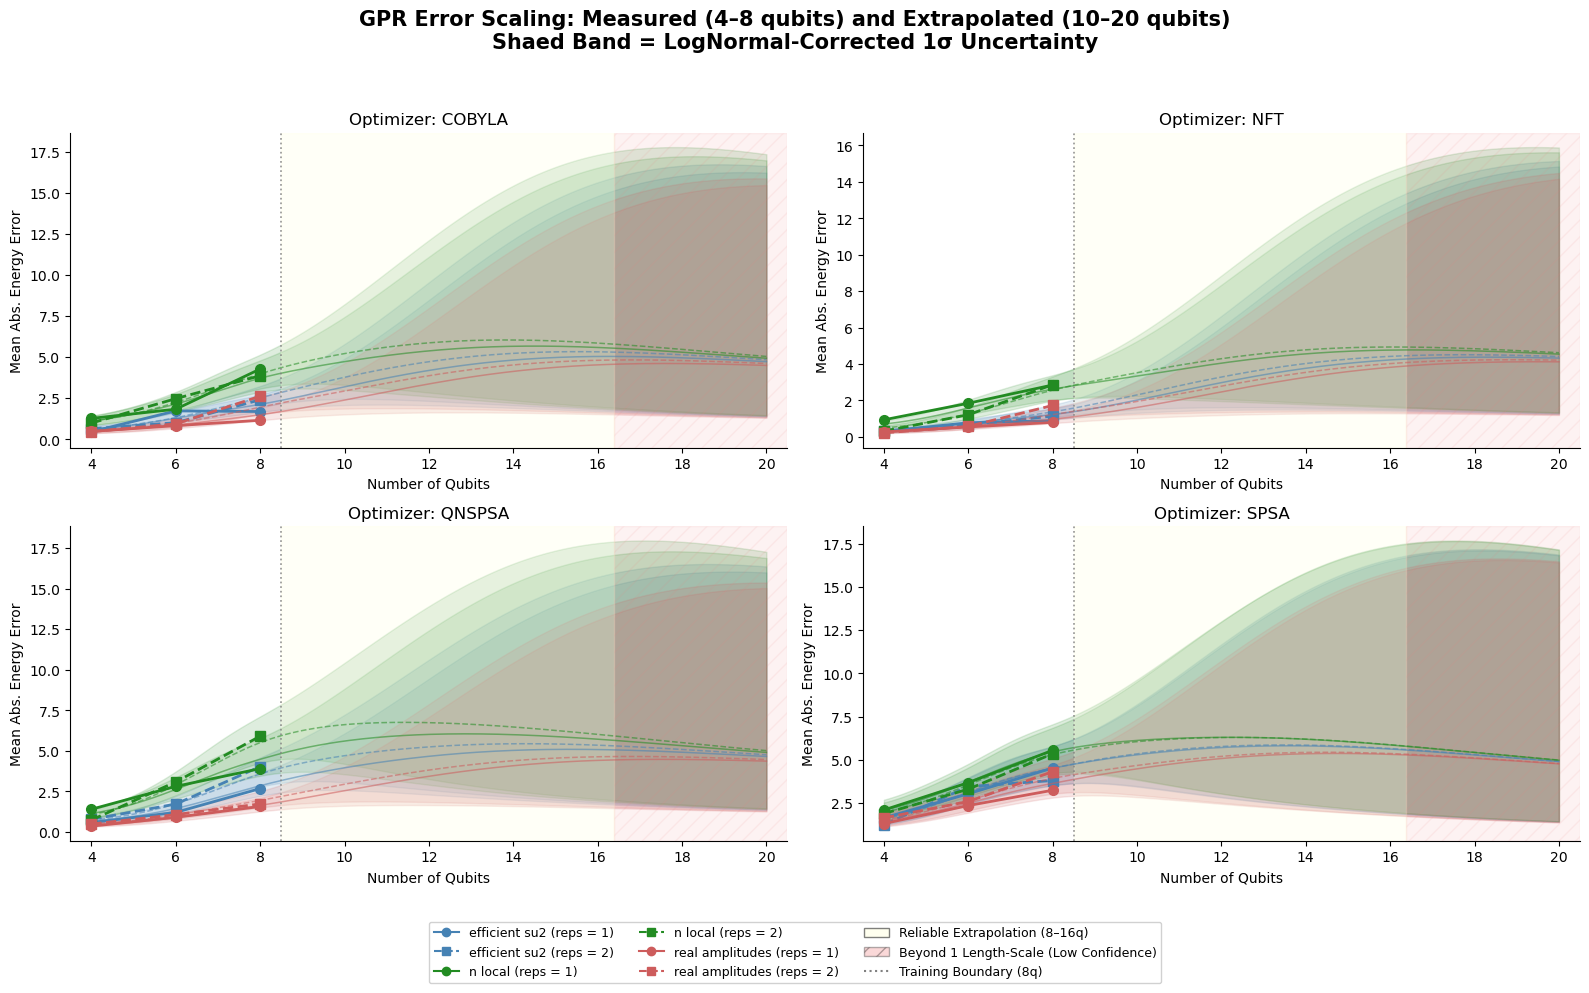

In [161]:
reliability_horizon = compute_reliability_horizon()

OPTIMIZERS = sorted(df['optimizer'].unique())
ANSATZ = sorted(df['ansatz'].unique())
COLORS = {'efficient_su2': 'steelblue', 'n_local': 'forestgreen', 'real_amplitudes': 'indianred'}
LS = {1: '-', 2: '--'} 
MK = {1: 'o', 2: 's'}

q_dense = np.linspace(4, 20, 200)

plt.figure(figsize=(16,10))

for i, opt in enumerate(OPTIMIZERS, start = 1):
    plt.subplot(2, 2, i) #  Makes panel i "current" - everything below targets it

    for ans in ANSATZ:
        for rep in [1, 2]:
            measured = df[(df.ansatz == ans) & (df.reps == rep) & (df.optimizer == opt)].sort_values('n_qubits')
            if measured.empty:
                continue
            plt.plot(measured['n_qubits'], measured['mean_abs_error'],
                     LS[rep], marker =MK[rep], markersize = 7, color = COLORS[ans], linewidth = 2)
            
            mu, sigma = predict_curve(ans, rep, opt, q_dense)
            low, high = lognormal_band(mu, sigma)
            plt.plot(q_dense, lognormal_mean(mu, sigma), LS[rep], color = COLORS[ans], linewidth = 1.1, alpha = 0.55)
            plt.fill_between(q_dense, low, high, color = COLORS[ans], alpha = 0.15)

    plt.axvline(8.5, color = 'grey', ls=":", linewidth = 1.25, alpha = 0.8)
    plt.axvspan(8.5, reliability_horizon, color = 'lightyellow', alpha = 0.25)
    plt.axvspan(reliability_horizon, 20.5, color = 'lightcoral', alpha = 0.1, hatch = '//')
    plt.title(f'Optimizer: {opt}', fontsize = 12)
    plt.xlabel('Number of Qubits')
    plt.ylabel('Mean Abs. Energy Error')
    plt.xlim(3.5, 20.5)
    plt.xticks([4, 6, 8, 10, 12, 14, 16, 18, 20])
    plt.gca().spines[['top', 'right']].set_visible(False)

handles = [
    plt.Line2D([0], [0], color = COLORS[a], linestyle = LS[r], marker = MK[r], ms=6,
               label = f'{a.replace("_", " ")} (reps = {r})')
            for a in ANSATZ for r in [1,2]
]
handles += [
    mpatches.Patch(facecolor = 'lightyellow', alpha = 0.5, label = f'Reliable Extrapolation (8\u2013{reliability_horizon:.0f}q)', edgecolor='black'),
    mpatches.Patch(facecolor = 'lightcoral', alpha = 0.3, hatch = '//', label = 'Beyond 1 Length-Scale (Low Confidence)', edgecolor= 'black'),
    plt.Line2D([0], [0], color = 'grey', ls=':', label = 'Training Boundary (8q)')
]

plt.figlegend(handles = handles, loc = 'lower center', ncol = 3, fontsize = 9, bbox_to_anchor = (0.5, 0), framealpha = 0.9)
plt.suptitle('GPR Error Scaling: Measured (4\u20138 qubits) and Extrapolated (10\u201320 qubits)\n'
             'Shaed Band = LogNormal-Corrected 1\u03c3 Uncertainty', fontsize = 15, fontweight = 'bold')
plt.tight_layout(rect=[0, 0.09, 1, 0.95])
plt.show()




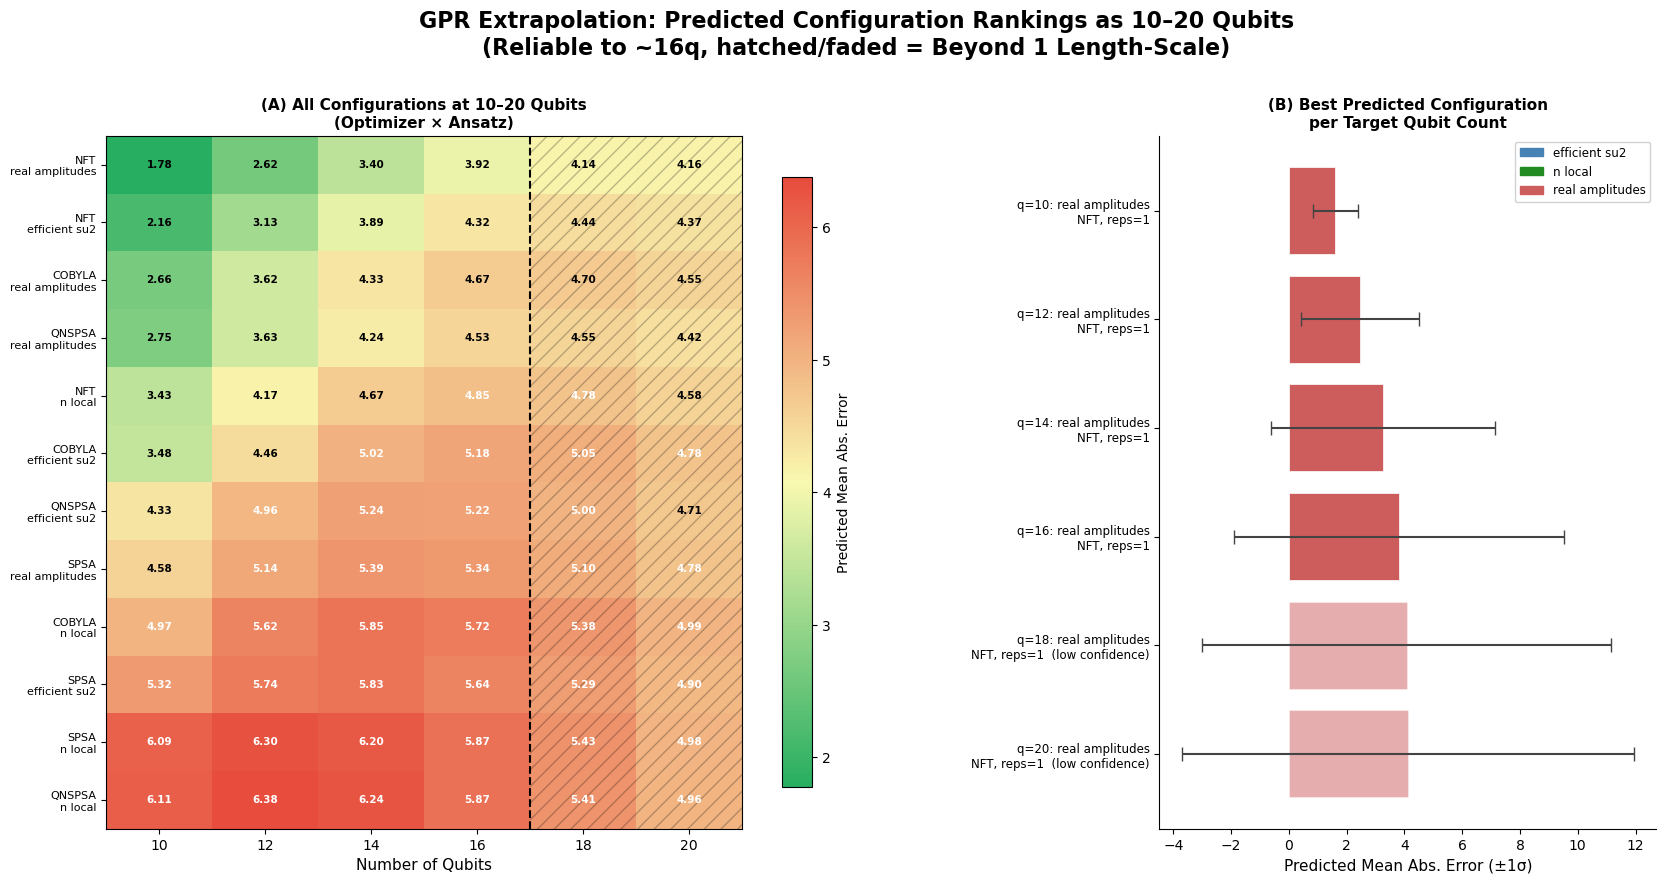

In [176]:
def plot_config_heatmap(df_new, target_q, reliability_horizon):
    heat_df = df_new.groupby(['n_qubits', 'optimizer', 'ansatz'])['pred'].mean().reset_index()
    heat_df['config'] = heat_df['optimizer'] + '\n' + heat_df['ansatz'].str.replace('_', ' ')
    pivot = heat_df.pivot(index='config', columns = 'n_qubits', values = 'pred').sort_values(by=target_q[0])

    cmap = LinearSegmentedColormap.from_list('gr', ['#27ae60', '#f9f9b0', '#e74c3c'])
    plt.imshow(pivot.values, cmap = cmap, aspect= 'auto')
    plt.colorbar(label = 'Predicted Mean Abs. Error', shrink = 0.88)

    plt.xticks(range(len(target_q)), [str(q) for q in target_q], fontsize=10)
    plt.yticks(range(len(pivot.index)), pivot.index, fontsize = 8)
    plt.xlabel('Number of Qubits', fontsize = 11)
    plt.title('(A) All Configurations at 10\u201320 Qubits\n(Optimizer \u00d7 Ansatz)', fontsize = 11, fontweight = 'bold')

    for i in range(len(pivot.index)):
        for j, q in enumerate(target_q):
            val = pivot.values[i, j]
            plt.text(j, i, f'{val:.2f}', ha = 'center', va = 'center', fontsize = 7.5, fontweight = 'bold', 
                     color = 'white' if val > pivot.values.mean() else 'black')
            if q > reliability_horizon:
                plt.gca().add_patch(plt.Rectangle((j-0.5, i - 0.5), 1, 1, fill=False, hatch = '//',
                                                  edgecolor = 'black', linewidth = 0, alpha = 0.25))
    horizon_col = sum(q <= reliability_horizon for q in target_q) - 0.5
    plt.axvline(horizon_col, color = 'black', ls = '--', linewidth = 1.5)

def plot_best_config_bars(df_new, target_q, reliability_horizon, colors):
    best = pd.DataFrame([df_new[df_new['n_qubits'] == q].sort_values('pred').iloc[0] for q in target_q])
    labels = [
        f"q={int(r.n_qubits)}: {r.ansatz.replace('_', ' ')}\n{r.optimizer}, reps={int(r.reps)}"
        + ('  (low confidence)' if r.n_qubits > reliability_horizon else '')
        for _, r in best.iterrows()
    ]
    bar_colors = [colors[r.ansatz] for _, r in best.iterrows()]
    alphas = [1.0 if r.n_qubits <= reliability_horizon else 0.5 for _, r in best.iterrows()]

    bars = plt.barh(range(len(best)), best['pred'], xerr=best['std'],
                     color=bar_colors, edgecolor='white', linewidth=0.5,
                     error_kw={'elinewidth': 1.5, 'capsize': 5, 'ecolor': '#444'})
    for bar, a in zip(bars, alphas):
        bar.set_alpha(a)

    plt.yticks(range(len(best)), labels, fontsize=8.5)
    plt.xlabel('Predicted Mean Abs. Error (\u00b11\u03c3)', fontsize = 11)
    plt.title('(B) Best Predicted Configuration\nper Target Qubit Count', fontsize = 11, fontweight = 'bold')
    plt.gca().spines[['top', 'right']].set_visible(False)
    plt.gca().invert_yaxis()
    plt.legend(handles = [mpatches.Patch(color = c, label = a.replace('_', " ")) for a,c in colors.items()],
               fontsize = 8.5, loc = 'upper right', framealpha = 0.9)
    
TARGET_Q = [10, 12, 14, 16, 18, 20]
df_new['pred'] = lognormal_mean(df_new['pred_log'], df_new['std_log'])
df_new['std'] = lognormal_std(df_new['pred_log'], df_new['std_log'])

plt.figure(figsize=(20, 9))
gs = gridspec.GridSpec(1, 2, wspace = 0.4, width_ratios = [1.6, 1])

plt.subplot(gs[0])
plot_config_heatmap(df_new, TARGET_Q, reliability_horizon)

plt.subplot(gs[1])
plot_best_config_bars(df_new, TARGET_Q, reliability_horizon, COLORS)

plt.suptitle(f"GPR Extrapolation: Predicted Configuration Rankings as 10\u201320 Qubits\n"
             f'(Reliable to ~{reliability_horizon:.0f}q, hatched/faded = Beyond 1 Length-Scale)',
             fontsize = 16, fontweight = 'bold', y = 1.02)
plt.show()